# Gym Member Clustering Pipeline
## K-Means vs Hierarchical Clustering
**Dataset:** fitness_cleaned.csv (1998 members, 33 features)  
**Goal:** Phan cum thanh vien dua tren hanh vi tap luyen + chi tieu

---
### Pipeline Overview
1. EDA – Kham pha du lieu
2. Feature Engineering – Chon & xu ly dac trung
3. Preprocessing – Scale + Encode
4. K-Means – Elbow method -> chon K toi uu -> train
5. Hierarchical Clustering – Cung K -> train + Dendrogram
6. Evaluation – Silhouette, Davies-Bouldin, Calinski-Harabasz
7. Comparison & Insights – So sanh & phan tich cum


## 1. Import Thu Vien

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score,
                             adjusted_rand_score,
                             normalized_mutual_info_score)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
PALETTE = ['#2E86AB', '#E84855', '#3BB273', '#F4A261', '#9B5DE5', '#F15BB5']

print('Libraries loaded!')
print(f'  pandas  {pd.__version__}')
print(f'  sklearn {__import__("sklearn").__version__}')
print(f'  scipy   {__import__("scipy").__version__}')


Libraries loaded!
  pandas  2.3.3
  sklearn 1.6.1
  scipy   1.16.3


## 2. Load & EDA Du Lieu

In [9]:
import os

print(os.listdir("/kaggle/input/datasets/trngvnthin/k-means/fitness_cleaned.csv"))

NotADirectoryError: [Errno 20] Not a directory: '/kaggle/input/datasets/trngvnthin/k-means/fitness_cleaned.csv'

In [2]:
DATA_PATH = "/kaggle/input/datasets/trngvnthin/k-means/fitness_cleaned.csv"  # <- doi path neu can
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
print(f'  Rows   : {df.shape[0]:,}')
print(f'  Columns: {df.shape[1]}')
df.head()


Dataset shape: (1998, 33)
  Rows   : 1,998
  Columns: 33


,age,membership_type,visit_per_week,days_per_week,attend_group_lesson,avg_time_check_in,avg_time_check_out,duration_in_gym_minutes,has_drink_subscription,personal_training,...,personal_training_hours,multi_location_access,last_visit_date,Mon,Tue,Wed,Thu,Fri,Sat,Sun
0,40,Premium,2,"Sat, Thu",False,08:39:00,10:37:00,118,False,False,...,0,True,2025-06-30,0,0,0,1,0,1,0
1,35,Standard,5,"Fri, Sat, Thu, Tue, Wed",True,15:45:00,18:43:00,178,False,False,...,0,False,2025-05-26,0,1,1,1,1,1,0
2,39,Standard,4,"Sun, Thu, Tue, Wed",True,13:35:00,14:37:00,62,True,True,...,4,False,2025-06-09,0,1,1,1,0,0,1
3,35,Basic,2,"Mon, Tue",False,17:06:00,18:39:00,93,True,True,...,7,False,2025-06-17,1,1,0,0,0,0,0
4,18,Standard,2,"Sun, Wed",False,14:16:00,16:57:00,161,True,True,...,3,True,2025-07-13,0,0,1,0,0,0,1


In [3]:
print('=== Data Types ===')
print(df.dtypes.value_counts())
print()
missing = df.isnull().sum()
print('=== Missing Values ===')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')
print()
print('=== Numerical Summary ===')
df.describe().T


=== Data Types ===
int64      12
object     11
bool        5
float64     5
Name: count, dtype: int64

=== Missing Values ===
No missing values!

=== Numerical Summary ===


,count,mean,std,min,25%,50%,75%,max
age,1998.0,30.591091,10.740041,12.0000,21.0000,30.0000,40.0000,49.0000
visit_per_week,1998.0,2.676176,1.234110,1.0000,2.0000,3.0000,3.0000,5.0000
duration_in_gym_minutes,1998.0,104.818819,43.363542,30.0000,67.0000,103.0000,142.0000,180.0000
subscription_price,1998.0,40.140140,15.457645,20.0000,30.0000,50.0000,50.0000,70.0000
adjusted_price,1998.0,36.596847,14.860914,15.0000,22.5000,37.5000,50.0000,70.0000
discount_rate,1998.0,0.057858,0.058296,0.0000,0.0000,0.0500,0.1000,0.1500
final_price,1998.0,34.471384,14.266186,12.7500,22.5000,31.8750,45.0000,70.0000
latitude,1998.0,35.818505,1.994180,32.7157,33.8366,36.7378,37.7749,38.5816
longitude,1998.0,-119.801068,1.864262,-122.4194,-121.8863,-119.7871,-118.1937,-117.1611
personal_training_hours,1998.0,2.305806,2.758167,0.0000,0.0000,1.0000,5.0000,8.0000


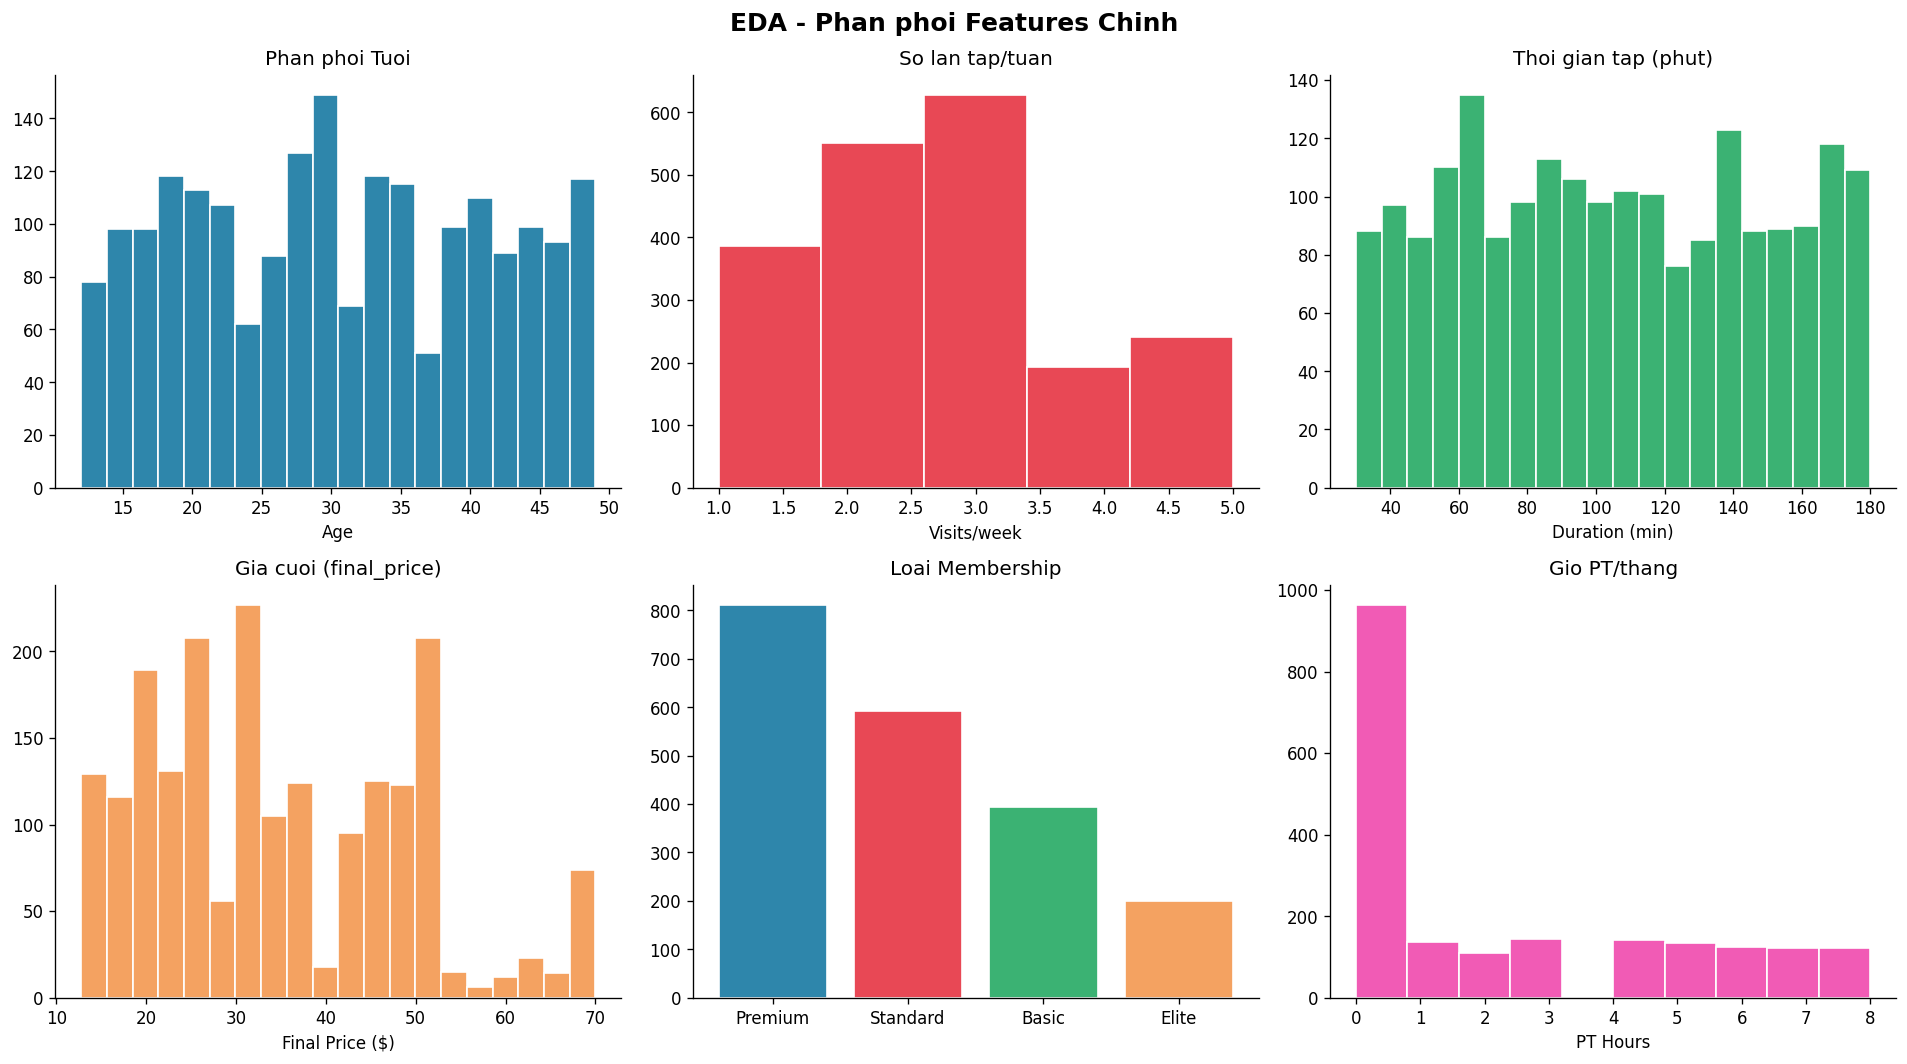

EDA chart saved!


In [3]:
# EDA - Phan phoi cac features chinh
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA - Phan phoi Features Chinh', fontsize=15, fontweight='bold')

axes[0,0].hist(df['age'], bins=20, color=PALETTE[0], edgecolor='white')
axes[0,0].set_title('Phan phoi Tuoi'); axes[0,0].set_xlabel('Age')

axes[0,1].hist(df['visit_per_week'], bins=5, color=PALETTE[1], edgecolor='white')
axes[0,1].set_title('So lan tap/tuan'); axes[0,1].set_xlabel('Visits/week')

axes[0,2].hist(df['duration_in_gym_minutes'], bins=20, color=PALETTE[2], edgecolor='white')
axes[0,2].set_title('Thoi gian tap (phut)'); axes[0,2].set_xlabel('Duration (min)')

axes[1,0].hist(df['final_price'], bins=20, color=PALETTE[3], edgecolor='white')
axes[1,0].set_title('Gia cuoi (final_price)'); axes[1,0].set_xlabel('Final Price ($)')

mem_counts = df['membership_type'].value_counts()
axes[1,1].bar(mem_counts.index, mem_counts.values,
              color=PALETTE[:len(mem_counts)], edgecolor='white')
axes[1,1].set_title('Loai Membership')

axes[1,2].hist(df['personal_training_hours'], bins=10, color=PALETTE[5], edgecolor='white')
axes[1,2].set_title('Gio PT/thang'); axes[1,2].set_xlabel('PT Hours')

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('EDA chart saved!')


## 3. Feature Engineering & Preprocessing

### Chien luoc chon features:
- **Hanh vi tap luyen:** `visit_per_week`, `duration_in_gym_minutes`, `personal_training_hours`, `checkin_hour`, `weekend_ratio`, ngay tap (Mon-Sun)
- **Hanh vi chi tieu:** `final_price`, `discount_rate`, `membership_type` (encoded), `subscription_model` (encoded)
- **Dich vu su dung:** `attend_group_lesson`, `has_drink_subscription`, `personal_training`, `uses_sauna`, `multi_location_access`


In [3]:
def labelEncode(column):
    label = LabelEncoder()
    df[column] = label.fit_transform(df[column])

# avg time each week
df['avg_time_week'] = df['duration_in_gym_minutes'] * df['visit_per_week']

# Weekend ratio: ty le tap cuoi tuan
day_cols = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['weekend_ratio'] = (df['Sat'] + df['Sun']) / (df[day_cols].sum(axis=1) + 1e-9)

# Encode categoricals
columns_cat = ['membership_type','subscription_model','discount_type','access_hours','self_identified_gender']

for c in columns_cat:
    labelEncode(c)

# le_membership   = LabelEncoder()
# le_subscription = LabelEncoder()
# df['membership_encoded']   = le_membership.fit_transform(df['membership_type'])
# df['subscription_encoded'] = le_subscription.fit_transform(df['subscription_model'])
# df['discount_type'] = 

# Boolean -> int
bool_cols = ['attend_group_lesson','has_drink_subscription',
             'personal_training','uses_sauna','multi_location_access']
for c in bool_cols:
    df[c] = df[c].astype(int)

# total service erollment customer
df['total_service'] = df[bool_cols].sum(axis=1)

WORKOUT_FEATURES  = ['personal_training_hours',
                    'weekend_ratio','avg_time_week','age','access_hours','self_identified_gender'] 

SPENDING_FEATURES = ['final_price','discount_rate','membership_type','subscription_model','discount_type'] 

SERVICE_FEATURES  = ['total_service']
ALL_FEATURES = WORKOUT_FEATURES + SPENDING_FEATURES + SERVICE_FEATURES

print(f'Total features: {len(ALL_FEATURES)}')
print(f'  Workout  : {len(WORKOUT_FEATURES)}')
print(f'  Spending : {len(SPENDING_FEATURES)}')
print(f'  Services : {len(SERVICE_FEATURES)}')
print(ALL_FEATURES)


Total features: 12
  Workout  : 6
  Spending : 5
  Services : 1
['personal_training_hours', 'weekend_ratio', 'avg_time_week', 'age', 'access_hours', 'self_identified_gender', 'final_price', 'discount_rate', 'membership_type', 'subscription_model', 'discount_type', 'total_service']


Data scaled: shape = (1998, 12)


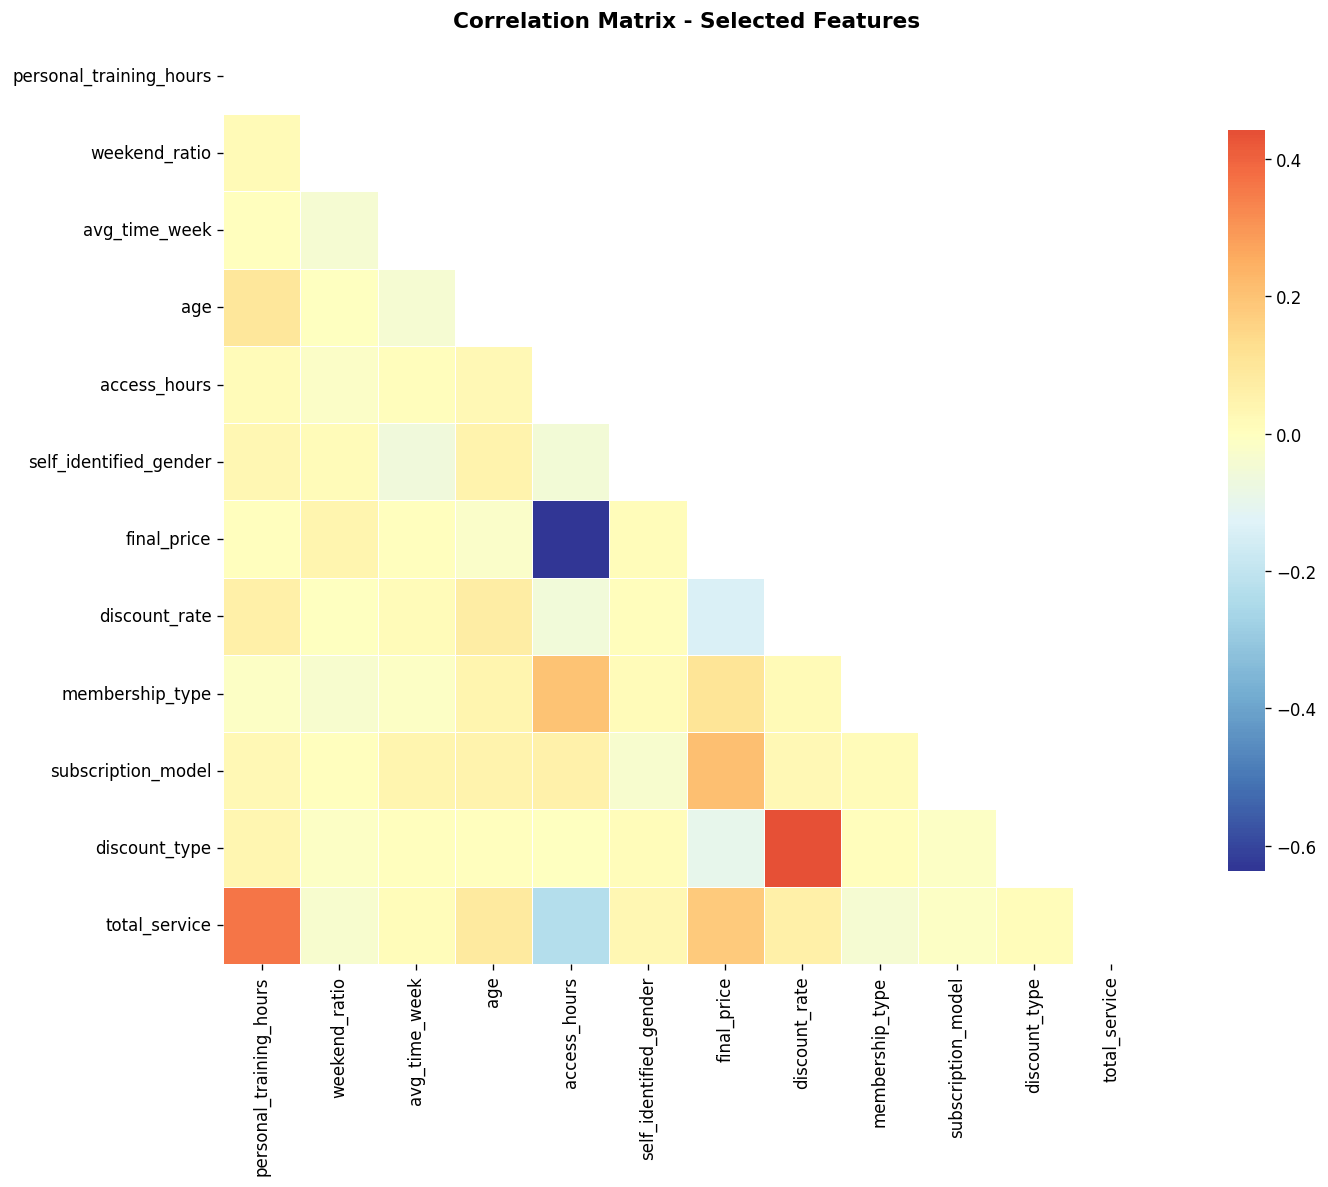

In [4]:
# StandardScaler
X = df[ALL_FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Data scaled: shape = {X_scaled.shape}')

# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlBu_r', center=0,
            annot=False, linewidths=0.3, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Selected Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. K-Means Clustering

### 4.1 Elbow Method - Chon K toi uu
Dung **WCSS** + **Silhouette Score** + **Davies-Bouldin** + **Calinski-Harabasz** de quyet dinh so cum.


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [6]:
K_RANGE = range(2, 11)
wcss_list, silhouette_list, db_list, ch_list = [], [], [], []

print('Computing Elbow metrics...')
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    wcss_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_pca, labels))
    db_list.append(davies_bouldin_score(X_pca, labels))
    ch_list.append(calinski_harabasz_score(X_pca, labels))
    print(f'  K={k:2d} | WCSS={km.inertia_:,.0f} | Sil={silhouette_list[-1]:.4f} '
          f'| DB={db_list[-1]:.4f} | CH={ch_list[-1]:.1f}')
print('Done!')


Computing Elbow metrics...
  K= 2 | WCSS=3,831 | Sil=0.4183 | DB=1.0138 | CH=1484.8
  K= 3 | WCSS=2,126 | Sil=0.4814 | DB=0.7632 | CH=2136.5
  K= 4 | WCSS=1,631 | Sil=0.4623 | DB=0.7815 | CH=2057.9
  K= 5 | WCSS=1,297 | Sil=0.4341 | DB=0.7554 | CH=2067.8
  K= 6 | WCSS=1,001 | Sil=0.4139 | DB=0.8166 | CH=2259.7
  K= 7 | WCSS=898 | Sil=0.3822 | DB=0.8798 | CH=2136.4
  K= 8 | WCSS=809 | Sil=0.3871 | DB=0.8542 | CH=2063.7
  K= 9 | WCSS=719 | Sil=0.3627 | DB=0.8554 | CH=2062.8
  K=10 | WCSS=647 | Sil=0.3639 | DB=0.8394 | CH=2058.9
Done!


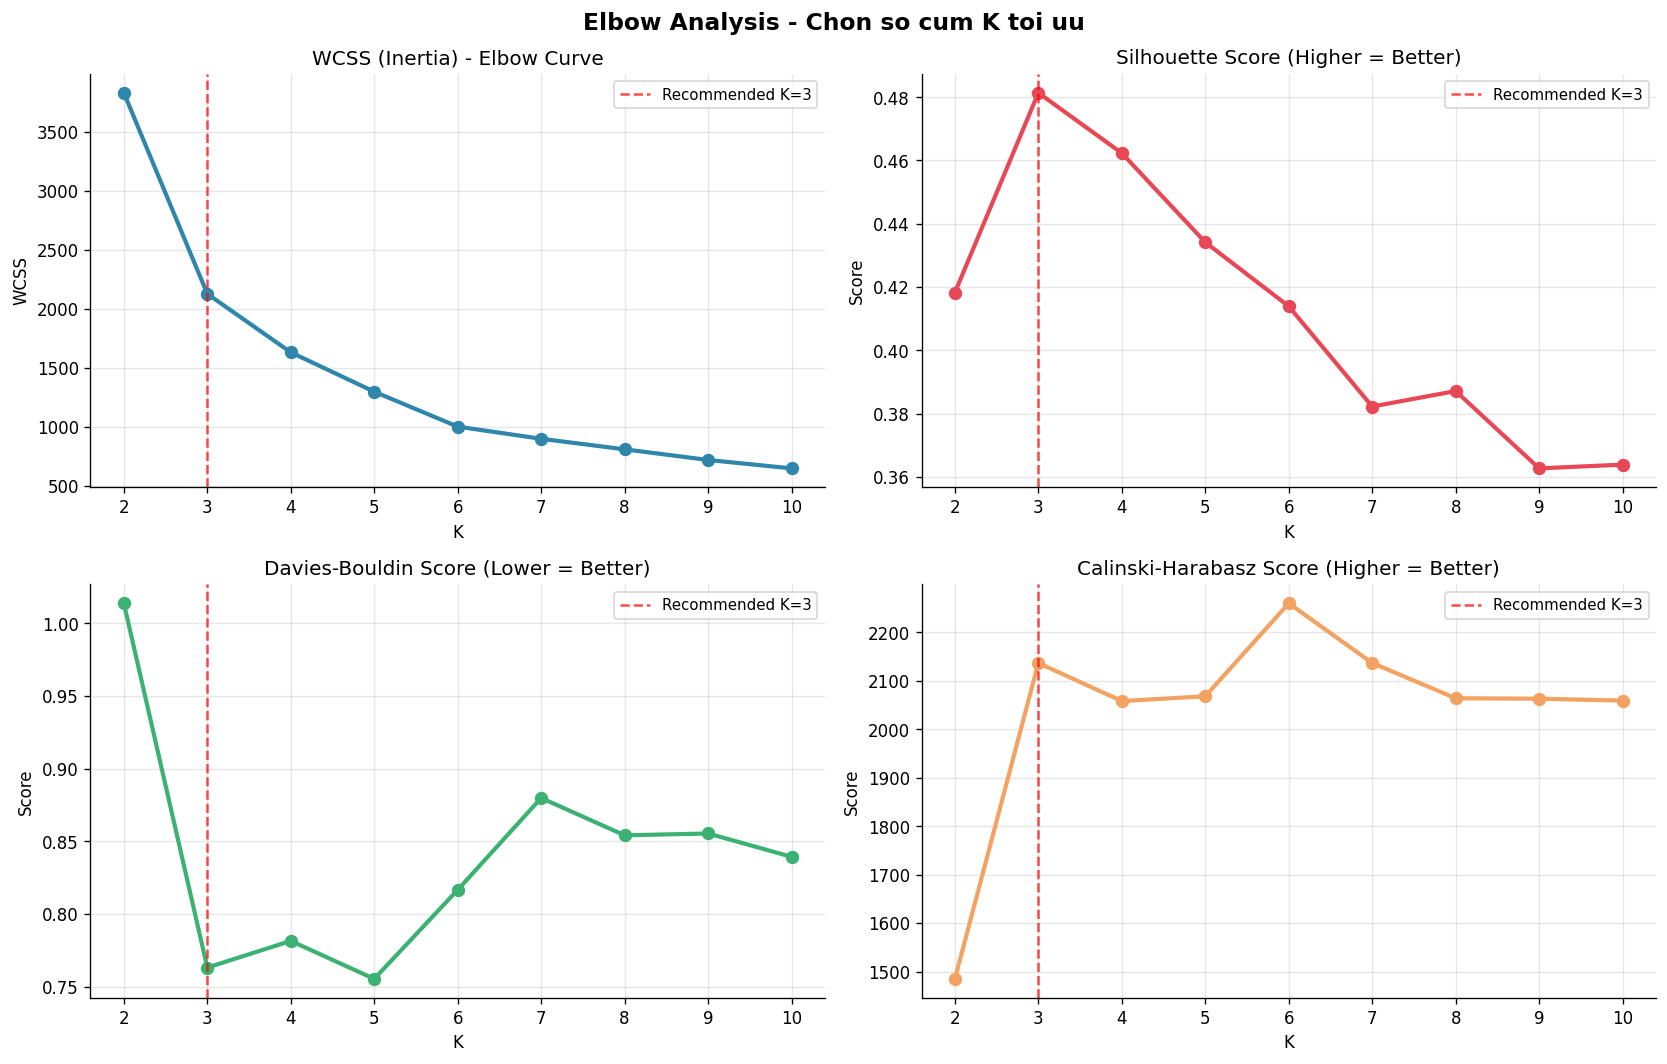

Recommended K = 3  (best Silhouette = 0.4814)


In [7]:
# Ve Elbow Chart
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Elbow Analysis - Chon so cum K toi uu', fontsize=14, fontweight='bold')

k_vals = list(K_RANGE)
best_sil_k = k_vals[np.argmax(silhouette_list)]

plots = [
    (axes[0,0], wcss_list,       'WCSS (Inertia) - Elbow Curve',           PALETTE[0], 'WCSS'),
    (axes[0,1], silhouette_list, 'Silhouette Score (Higher = Better)',      PALETTE[1], 'Score'),
    (axes[1,0], db_list,         'Davies-Bouldin Score (Lower = Better)',   PALETTE[2], 'Score'),
    (axes[1,1], ch_list,         'Calinski-Harabasz Score (Higher = Better)',PALETTE[3], 'Score'),
]
for ax, vals, title, color, ylabel in plots:
    ax.plot(k_vals, vals, 'o-', color=color, linewidth=2.5, markersize=7)
    ax.axvline(x=best_sil_k, color='red', linestyle='--', alpha=0.7,
               label=f'Recommended K={best_sil_k}')
    ax.set_title(title); ax.set_xlabel('K'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Recommended K = {best_sil_k}  (best Silhouette = {max(silhouette_list):.4f})')


In [8]:
# Train K-Means
# Co the thay K_OPTIMAL neu muon thu so cum khac
K_OPTIMAL = best_sil_k
print(f'Using K = {K_OPTIMAL}')

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10, max_iter=300)
df['kmeans_cluster'] = kmeans.fit_predict(X_pca)

print('\nK-Means Cluster Distribution:')
for c, n in df['kmeans_cluster'].value_counts().sort_index().items():
    print(f'  Cluster {c}: {n:4d} members ({n/len(df)*100:.1f}%)')


Using K = 3

K-Means Cluster Distribution:
  Cluster 0:  762 members (38.1%)
  Cluster 1:  434 members (21.7%)
  Cluster 2:  802 members (40.1%)


## 5. Hierarchical Clustering

Dung **Ward linkage** voi cung K nhu K-Means de so sanh cong bang.  
Dendrogram duoc ve tren **200-member sample** de co the doc duoc.


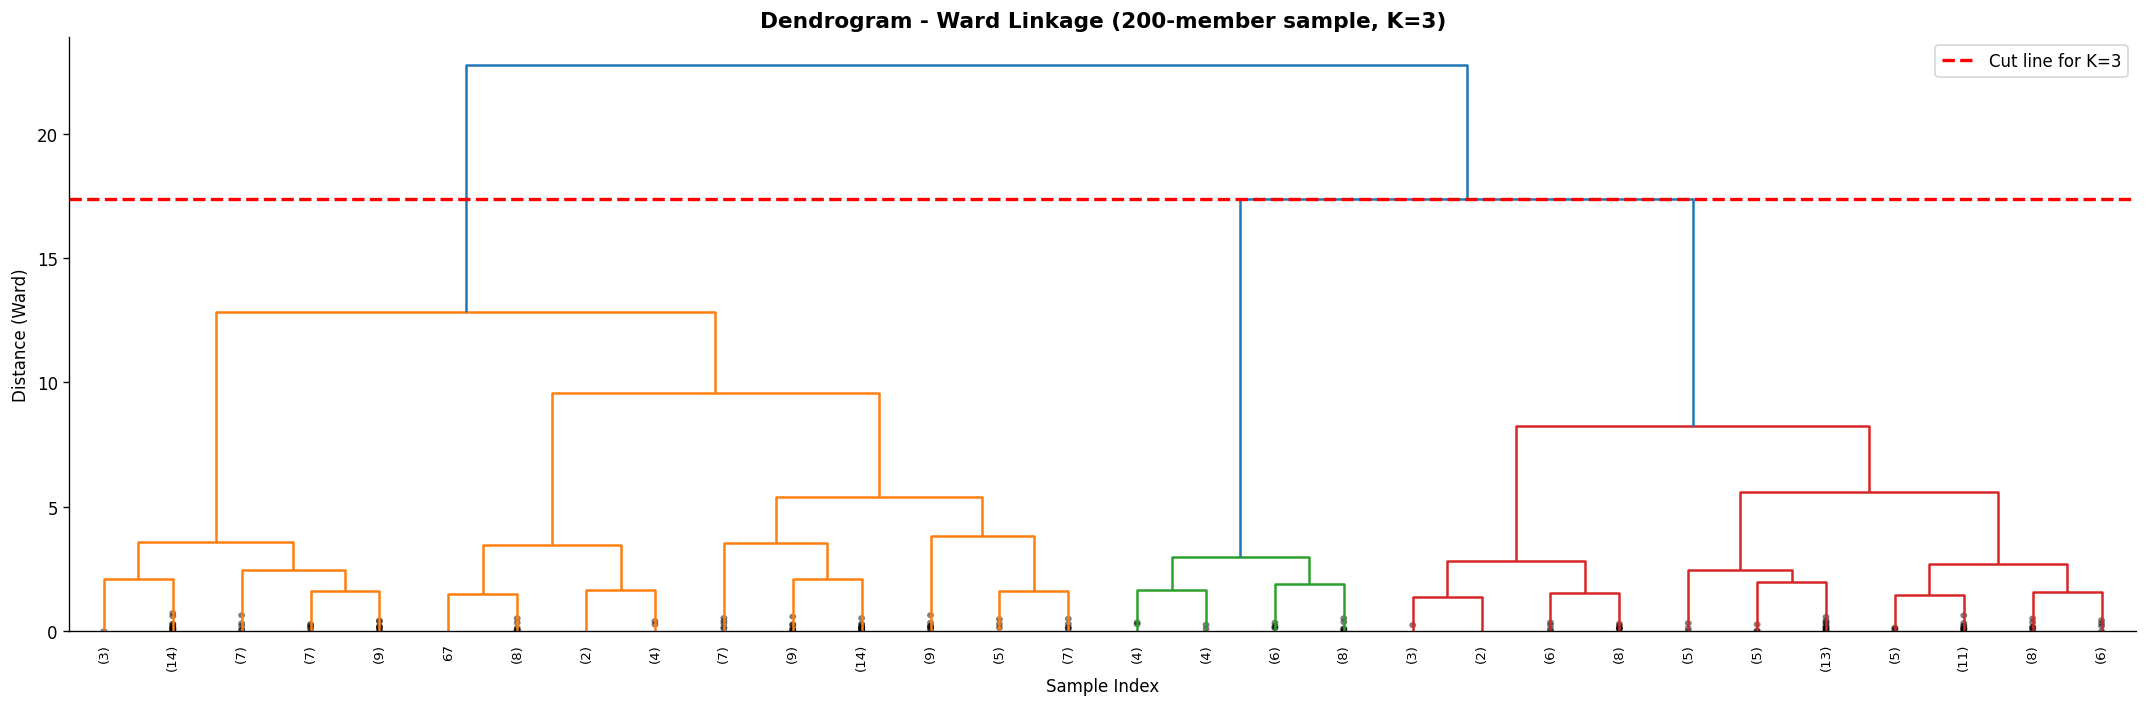

Dendrogram saved! Cat tai K=3 cum.


In [9]:
# Dendrogram tren sample 200
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), size=200, replace=False)
X_sample   = X_pca[sample_idx]
Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(18, 6))
cut_height = Z[-K_OPTIMAL+1, 2]
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           show_contracted=True,
           color_threshold=cut_height)
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=2,
           label=f'Cut line for K={K_OPTIMAL}')
ax.set_title(f'Dendrogram - Ward Linkage (200-member sample, K={K_OPTIMAL})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Distance (Ward)')
ax.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Dendrogram saved! Cat tai K={K_OPTIMAL} cum.')


In [10]:
# Train Hierarchical (full dataset)
hc = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
df['hc_cluster'] = hc.fit_predict(X_pca)

print('Hierarchical Cluster Distribution:')
for c, n in df['hc_cluster'].value_counts().sort_index().items():
    print(f'  Cluster {c}: {n:4d} members ({n/len(df)*100:.1f}%)')


Hierarchical Cluster Distribution:
  Cluster 0:  417 members (20.9%)
  Cluster 1:  780 members (39.0%)
  Cluster 2:  801 members (40.1%)


## 6. Danh Gia & So Sanh 2 Mo Hinh

| Metric | Y nghia | Tot hon khi |
|--------|---------|-------------|
| **Silhouette Score** | Gan ket noi cum vs tach biet lien cum | **Cao hon** (max=1) |
| **Davies-Bouldin** | Ty so phan tan trong/giua cum | **Thap hon** (min=0) |
| **Calinski-Harabasz** | Ty so phuong sai giua/trong cum | **Cao hon** |


In [11]:
km_labels = df['kmeans_cluster'].values
hc_labels = df['hc_cluster'].values

km_sil = silhouette_score(X_pca, km_labels)
hc_sil = silhouette_score(X_pca, hc_labels)
km_db  = davies_bouldin_score(X_pca, km_labels)
hc_db  = davies_bouldin_score(X_pca, hc_labels)
km_ch  = calinski_harabasz_score(X_pca, km_labels)
hc_ch  = calinski_harabasz_score(X_pca, hc_labels)

metrics_df = pd.DataFrame({
    'Model'              : ['K-Means', 'Hierarchical (Ward)'],
    'Silhouette (high)'  : [km_sil, hc_sil],
    'Davies-Bouldin (low)': [km_db, hc_db],
    'Calinski-Harabasz (high)': [km_ch, hc_ch],
}).set_index('Model')

print('=' * 60)
print('EVALUATION METRICS COMPARISON')
print('=' * 60)
print(metrics_df.round(4).to_string())
print('=' * 60)

sil_winner = 'K-Means' if km_sil >= hc_sil else 'Hierarchical'
db_winner  = 'K-Means' if km_db  <= hc_db  else 'Hierarchical'
ch_winner  = 'K-Means' if km_ch  >= hc_ch  else 'Hierarchical'
print(f'Winner - Silhouette     : {sil_winner}')
print(f'Winner - Davies-Bouldin : {db_winner}')
print(f'Winner - Calinski-Harab : {ch_winner}')


EVALUATION METRICS COMPARISON
                     Silhouette (high)  Davies-Bouldin (low)  Calinski-Harabasz (high)
Model                                                                                 
K-Means                         0.4814                0.7632                 2136.4828
Hierarchical (Ward)             0.4768                0.7716                 2065.7719
Winner - Silhouette     : K-Means
Winner - Davies-Bouldin : K-Means
Winner - Calinski-Harab : K-Means


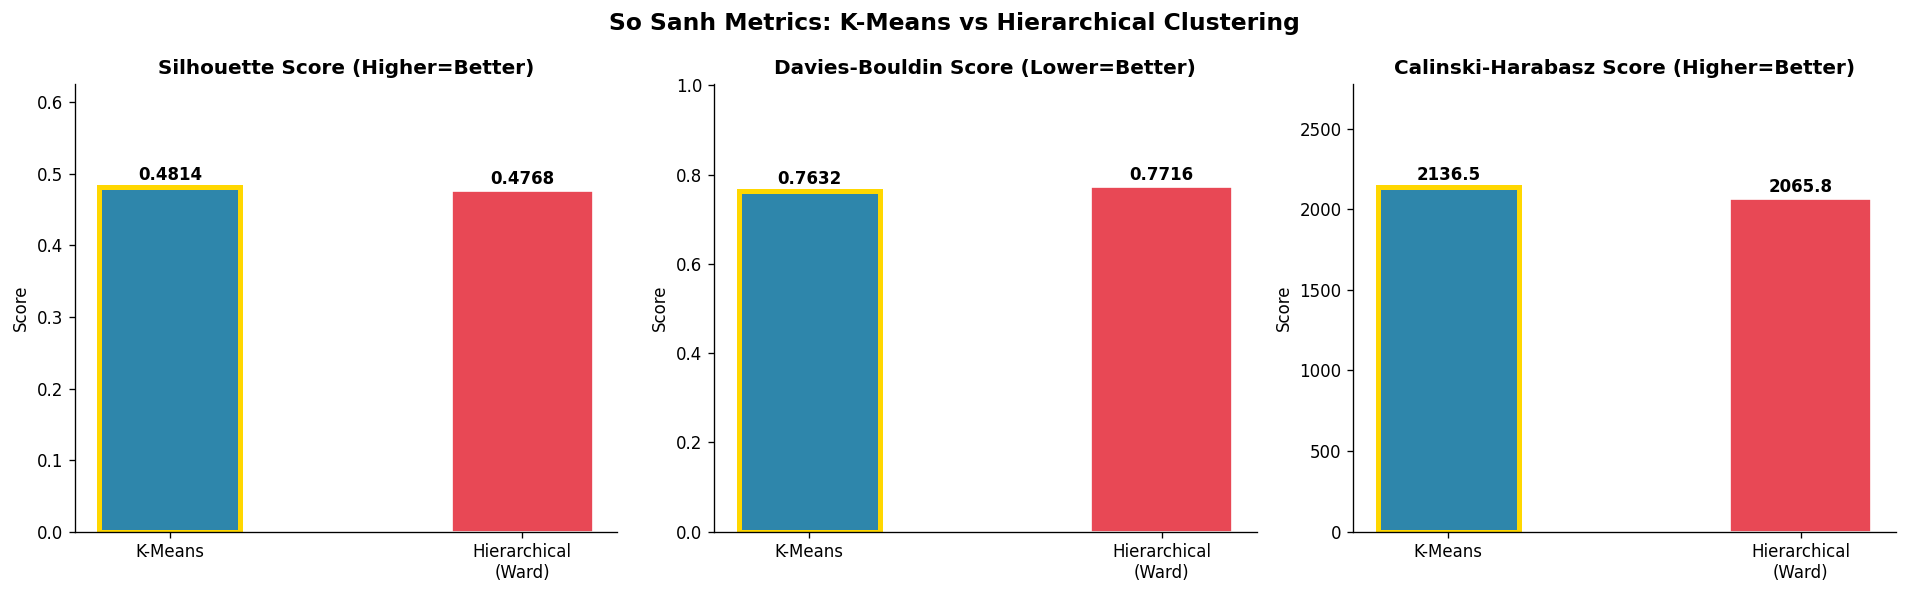

Gold border = winner cho moi metric


In [12]:
# Bar chart so sanh
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('So Sanh Metrics: K-Means vs Hierarchical Clustering',
             fontsize=14, fontweight='bold')

models = ['K-Means', 'Hierarchical\n(Ward)']
colors = [PALETTE[0], PALETTE[1]]

data_sets = [
    (axes[0], [km_sil, hc_sil], 'Silhouette Score (Higher=Better)', 'max'),
    (axes[1], [km_db,  hc_db ], 'Davies-Bouldin Score (Lower=Better)', 'min'),
    (axes[2], [km_ch,  hc_ch ], 'Calinski-Harabasz Score (Higher=Better)', 'max'),
]

for ax, vals, title, mode in data_sets:
    bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.4)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(vals) * 1.3)
    best_idx = np.argmax(vals) if mode == 'max' else np.argmin(vals)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        fmt = f'{v:.4f}' if abs(v) < 1000 else f'{v:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                fmt, ha='center', fontweight='bold')
        if i == best_idx:
            bar.set_edgecolor('gold'); bar.set_linewidth(3)

plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gold border = winner cho moi metric')


## 7. Truc Quan Hoa Cum bang PCA

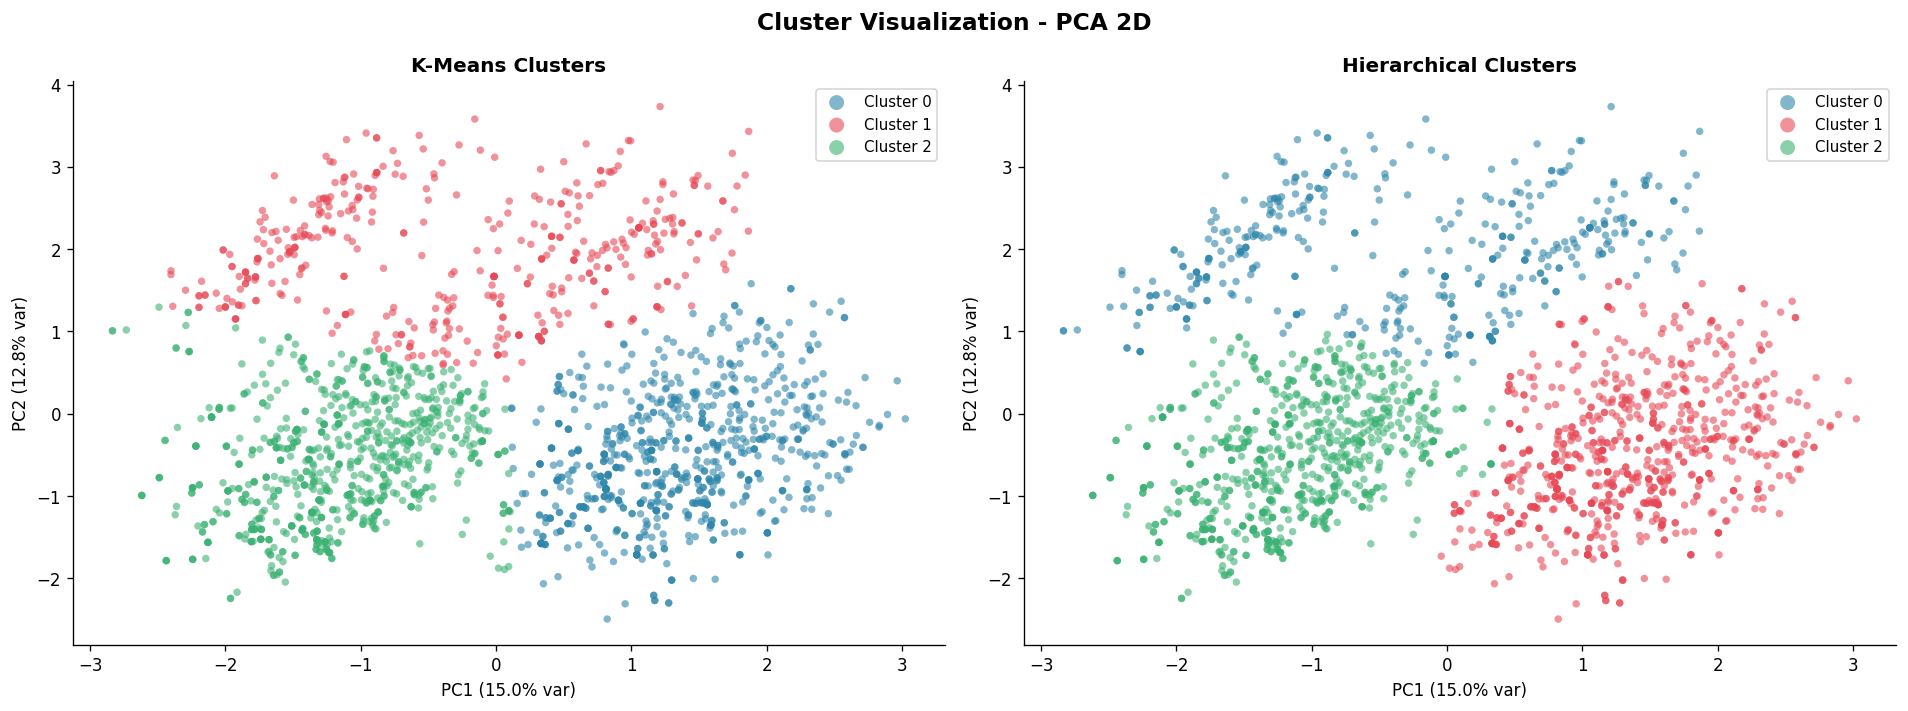

In [13]:
# PCA 2D
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cluster Visualization - PCA 2D', fontsize=14, fontweight='bold')

for ax, labels, title in zip(axes,
    [km_labels, hc_labels],
    ['K-Means Clusters', 'Hierarchical Clusters']):
    for k in range(K_OPTIMAL):
        mask = labels == k
        ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                   c=PALETTE[k % len(PALETTE)], label=f'Cluster {k}',
                   alpha=0.6, s=20, edgecolors='none')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
    ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.savefig('pca2d_clusters.png', bbox_inches='tight', dpi=150)
plt.show()


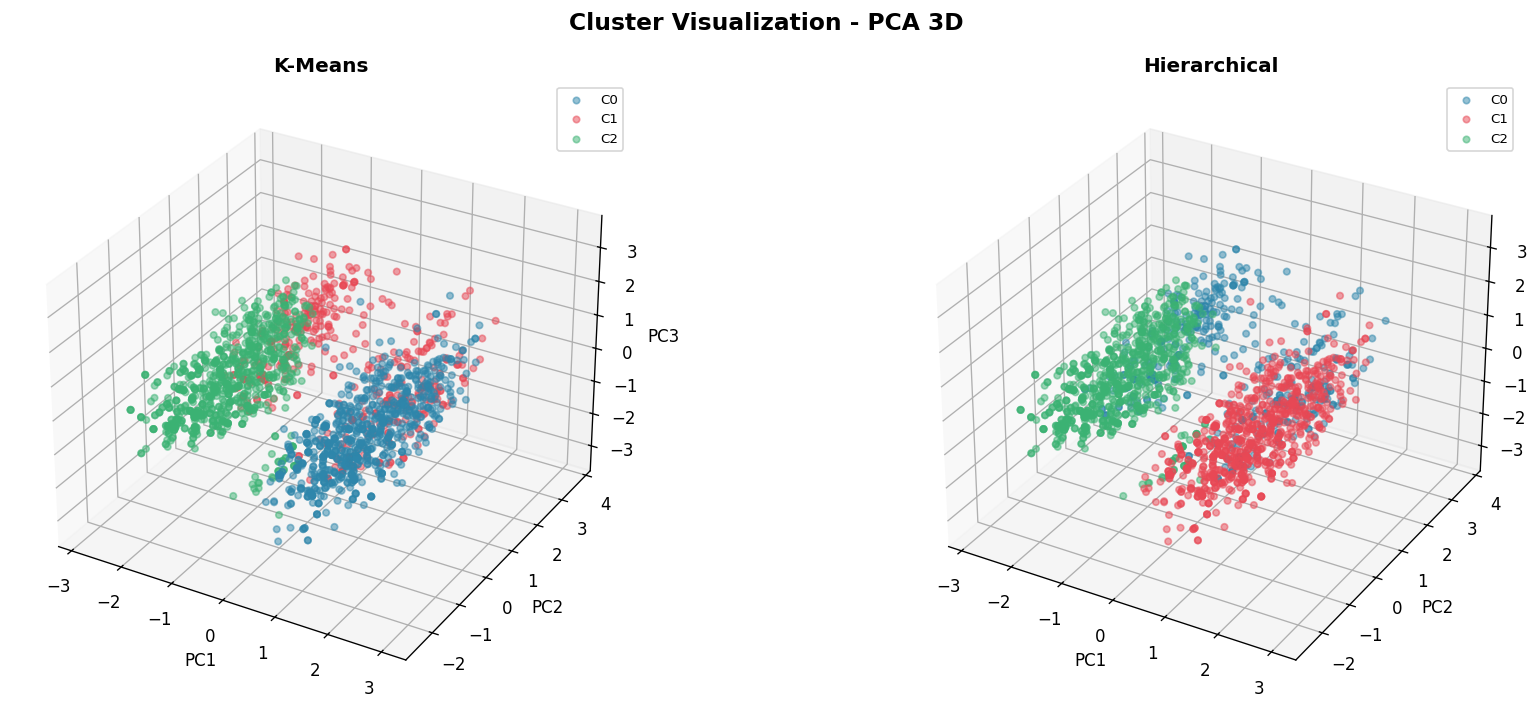

In [14]:
# PCA 3D
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Cluster Visualization - PCA 3D', fontsize=14, fontweight='bold')

for idx, (labels, title) in enumerate(zip(
    [km_labels, hc_labels], ['K-Means', 'Hierarchical'])):
    ax = fig.add_subplot(1, 2, idx+1, projection='3d')
    for k in range(K_OPTIMAL):
        mask = labels == k
        ax.scatter(X_pca3[mask,0], X_pca3[mask,1], X_pca3[mask,2],
                   c=PALETTE[k % len(PALETTE)], label=f'C{k}',
                   alpha=0.5, s=15)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('pca3d_clusters.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. Phan Tich Profile Tung Cum (K-Means)

In [15]:
profile_num = ['visit_per_week','duration_in_gym_minutes','personal_training_hours',
               'avg_time_week','weekend_ratio','final_price','discount_rate',
               'attend_group_lesson','has_drink_subscription',
               'personal_training','uses_sauna','multi_location_access']

profile = df.groupby('kmeans_cluster')[profile_num].mean().round(3)
print('K-Means Cluster Profiles (mean values):')
print(profile.to_string())

print('\nMembership Type Distribution per Cluster (%):')
mem_dist = (pd.crosstab(df['kmeans_cluster'], df['membership_type'],
                        normalize='index') * 100).round(1)
print(mem_dist.to_string())


K-Means Cluster Profiles (mean values):
                visit_per_week  duration_in_gym_minutes  personal_training_hours  avg_time_week  weekend_ratio  final_price  discount_rate  attend_group_lesson  has_drink_subscription  personal_training  uses_sauna  multi_location_access
kmeans_cluster                                                                                                                                                                                                                               
0                        2.626                  104.444                    2.245        277.291          0.300       48.089          0.037                0.555                   0.490              0.513       0.531                  0.815
1                        2.846                  107.127                    3.274        299.378          0.286       30.301          0.138                0.539                   0.528              0.694       0.569                  0.606
2       

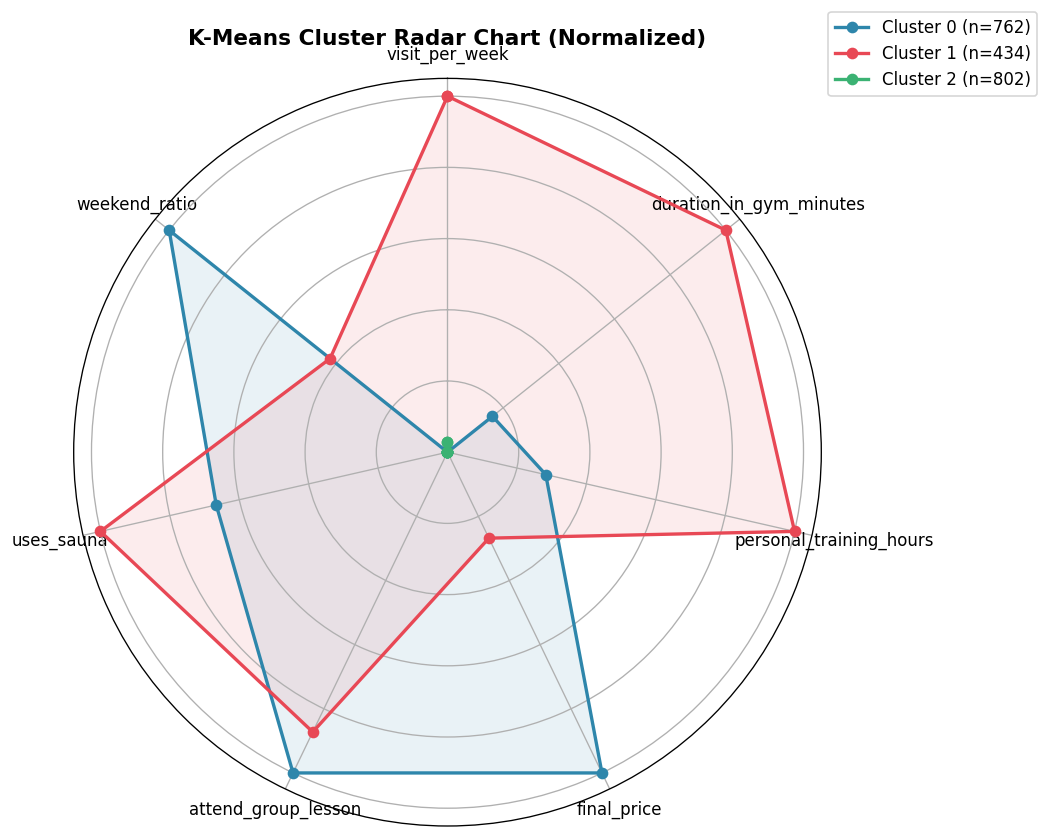

In [16]:
# Radar chart
radar_features = ['visit_per_week','duration_in_gym_minutes',
                  'personal_training_hours','final_price',
                  'attend_group_lesson','uses_sauna','weekend_ratio']

radar_data = df.groupby('kmeans_cluster')[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, size=10)
ax.set_yticklabels([])
ax.set_title('K-Means Cluster Radar Chart (Normalized)', fontsize=13, fontweight='bold', pad=20)

for k in range(K_OPTIMAL):
    vals = radar_norm.iloc[k].tolist() + [radar_norm.iloc[k].tolist()[0]]
    ax.plot(angles, vals, 'o-', linewidth=2, color=PALETTE[k % len(PALETTE)],
            label=f'Cluster {k} (n={int((km_labels==k).sum())})')
    ax.fill(angles, vals, alpha=0.1, color=PALETTE[k % len(PALETTE)])

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('radar_clusters.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. Muc Do Dong Thuan Giua 2 Mo Hinh

Agreement: K-Means vs Hierarchical
  Adjusted Rand Index (ARI) : 0.9023  (1.0 = perfect)
  Normalized Mutual Info    : 0.8450  (1.0 = perfect)


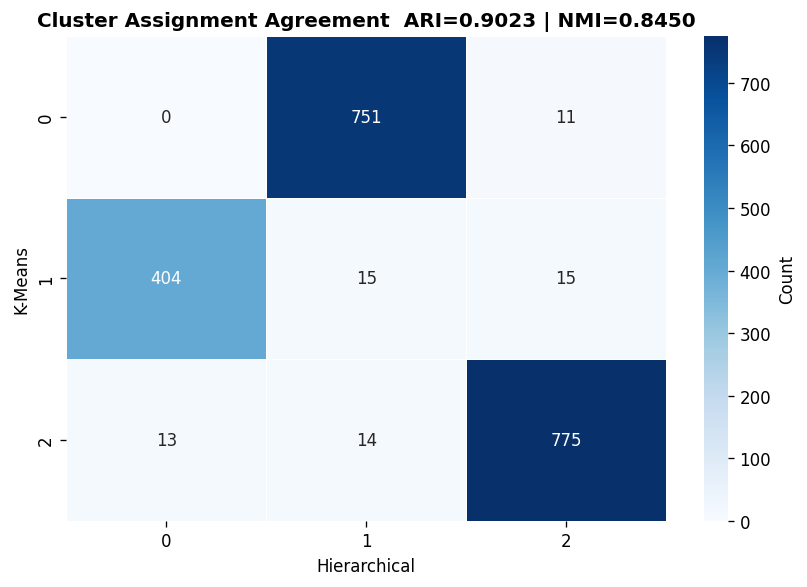

In [17]:
ari = adjusted_rand_score(km_labels, hc_labels)
nmi = normalized_mutual_info_score(km_labels, hc_labels)

print('=' * 55)
print('Agreement: K-Means vs Hierarchical')
print('=' * 55)
print(f'  Adjusted Rand Index (ARI) : {ari:.4f}  (1.0 = perfect)')
print(f'  Normalized Mutual Info    : {nmi:.4f}  (1.0 = perfect)')
print('=' * 55)

conf = pd.crosstab(df['kmeans_cluster'], df['hc_cluster'],
                   rownames=['K-Means'], colnames=['Hierarchical'])

plt.figure(figsize=(7, 5))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title(f'Cluster Assignment Agreement  ARI={ari:.4f} | NMI={nmi:.4f}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('agreement_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


## 10. Ket Luan & Khuyen Nghi

In [18]:
print('=' * 65)
print('          FINAL COMPARISON SUMMARY')
print('=' * 65)
print(f'  Dataset    : {len(df):,} gym members | {len(ALL_FEATURES)} features')
print(f'  Optimal K  : {K_OPTIMAL}')
print()
print(f'  {"Metric":<28} {"K-Means":>12} {"Hierarchical":>14} {"Winner":>12}')
print(f'  {"-"*68}')

scores = [
    ('Silhouette Score (high)',      km_sil, hc_sil, 'max'),
    ('Davies-Bouldin Score (low)',   km_db,  hc_db,  'min'),
    ('Calinski-Harabasz (high)',     km_ch,  hc_ch,  'max'),
]
wins = {'K-Means': 0, 'Hierarchical': 0}
for name, km_v, hc_v, mode in scores:
    if mode == 'max':
        winner = 'K-Means' if km_v >= hc_v else 'Hierarchical'
    else:
        winner = 'K-Means' if km_v <= hc_v else 'Hierarchical'
    wins[winner] += 1
    fmt = '.4f' if abs(km_v) < 1000 else '.1f'
    print(f'  {name:<28} {km_v:>12{fmt}} {hc_v:>14{fmt}} {winner:>12}')

print(f'  {"-"*68}')
print(f'  Wins -> K-Means: {wins["K-Means"]} | Hierarchical: {wins["Hierarchical"]}')
overall = 'K-Means' if wins['K-Means'] > wins['Hierarchical'] else 'Hierarchical'
print(f'  OVERALL WINNER: {overall}')



          FINAL COMPARISON SUMMARY
  Dataset    : 1,998 gym members | 12 features
  Optimal K  : 3

  Metric                            K-Means   Hierarchical       Winner
  --------------------------------------------------------------------
  Silhouette Score (high)            0.4814         0.4768      K-Means
  Davies-Bouldin Score (low)         0.7632         0.7716      K-Means
  Calinski-Harabasz (high)           2136.5         2065.8      K-Means
  --------------------------------------------------------------------
  Wins -> K-Means: 3 | Hierarchical: 0
  OVERALL WINNER: K-Means


## 11. Export Ket Qua

In [20]:
df.to_csv('fitness_clustered_results.csv', index=False)

print('Exported files:')
print('  fitness_clustered_results.csv  - Dataset voi cluster labels')
print('  eda_distributions.png')
print('  correlation_heatmap.png')
print('  elbow_analysis.png')
print('  dendrogram.png')
print('  metrics_comparison.png')
print('  pca2d_clusters.png')
print('  pca3d_clusters.png')
print('  radar_clusters.png')
print('  agreement_heatmap.png')


Exported files:
  fitness_clustered_results.csv  - Dataset voi cluster labels
  eda_distributions.png
  correlation_heatmap.png
  elbow_analysis.png
  dendrogram.png
  metrics_comparison.png
  pca2d_clusters.png
  pca3d_clusters.png
  radar_clusters.png
  agreement_heatmap.png
